In [1]:
%load_ext watermark


In [2]:
import itertools as it
import os

import matplotlib as mpl
from matplotlib import pyplot as plt
from phyloframe import _auxlib as pfa
from phyloframe import legacy as pfl
from pyfonts import load_google_font
import seaborn as sns
from teeplot import teeplot as tp

import pylib  # noqa: F401


/opt/hostedtoolcache/Python/3.11.14/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-04T22:16:37.148276+00:00

Python implementation: CPython
Python version       : 3.11.14
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

matplotlib: 3.10.0
teeplot   : 1.4.2
seaborn   : 0.13.2
pylib     : 0.0.0
phyloframe: 0.1.0

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-04-fossil-layers")
teeplot_subdir


'2026-03-04-fossil-layers'

In [5]:
pfa.seed_random(1)


In [6]:
font = load_google_font("Merriweather", weight=300)
mpl.font_manager.fontManager.addfont(font.get_file())
plt.rcParams["font.family"] = font.get_name()


## Prep Data


In [7]:
df_pure = pfl.alifestd_join_roots(
    pylib.read_parquet_with_retry("https://osf.io/download/pfvsg/"),
)
df_pure


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,510,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,1022,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,1534,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,3070,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99950,99950,999556085,99744,151216,1,64,bf7ffeba00024eb10a68ef4ccad354610049ce12,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,439435.0,False,False
99951,99951,999555051,97585,151219,1,64,bf7ffeb400024eb40a68ef4cc40779dd0049ce67,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,438401.0,False,False
99952,99952,999592311,99337,151222,1,64,bf7ffeb500024eb70a68af4c4cd76dc10049cec3,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,475661.0,False,False
99953,99953,999522298,97024,151225,1,64,bf7ffeb400024eba0268ef4c5da3b9c90049cf24,genome_purifyingonly,1.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingonly,False,1249.0,8761.0,405648.0,False,False


In [8]:
df_sweep = pfl.alifestd_join_roots(
    pylib.read_parquet_with_retry("https://osf.io/download/nk69s/"),
)
df_sweep


,id,dstream_data_id,ancestor_id,dstream_rank,hstrat_differentia_bitwidth,dstream_S,data_hex,genomeFlavor,globalSeed,nCol,...,CEREBRASLIB_TRAITLOGGER_DSTREAM_ALGO_NAME,CEREBRASLIB_HSTRAT_T_DILATION,CEREBRASLIB_HSTRAT_DSTREAM_ALGO_NAME,ASYNC_GA_GENOME_FLAVOR,is_extant,layer,layer_T,position,is_root,is_oldest_root
0,0,9223372036854775807,0,0,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,True,True
1,1,9223372036854775807,0,2046,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
2,2,9223372036854775807,1,15870,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
3,3,9223372036854775807,2,16287,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
4,4,9223372036854775807,3,16383,1,64,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99872,99872,999754987,99704,147913,1,64,c9477d70000241cadfb756bb95f5820600483125,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,638337.0,False,False
99873,99873,999934079,99643,147915,1,64,c9478350000241ccdfb716bb34f586c60048316f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,817429.0,False,False
99874,99874,999989329,99507,147918,1,64,c9478cc0000241cfdfb756bb2bf18946004831c1,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,872679.0,False,False
99875,99875,999919661,99699,147920,1,64,c9477d10000241d1dfb756bb26f594c60048320f,genome_purifyingsweep,2.0,755.0,...,steady_algo,32.0,hybrid_0_steady_1_tilted_2_algo,genome_purifyingsweep,False,1249.0,9873.0,803011.0,False,False


In [9]:
dfs = []
for df in (df_pure, df_sweep):
    df["x"] = df["position"] // df["nCol"]
    df["x_"] = df["x"] / df["nRow"]
    df["y"] = df["position"] % df["nCol"]
    df["y_"] = df["y"] / df["nCol"]

    df["origin_time"] = df["dstream_rank"]

    dfs.append(df)

df_pure, df_sweep = dfs


## Plot Layer Tree


/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1120) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=vertical+regime=pure+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=vertical+regime=pure+viz=draw-scatter-tree+ext=.png


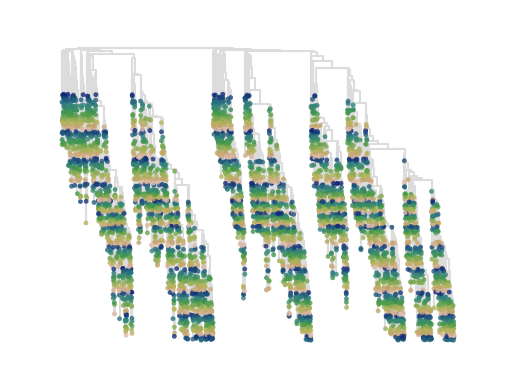

/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1119) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=horizontal+regime=pure+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=horizontal+regime=pure+viz=draw-scatter-tree+ext=.png


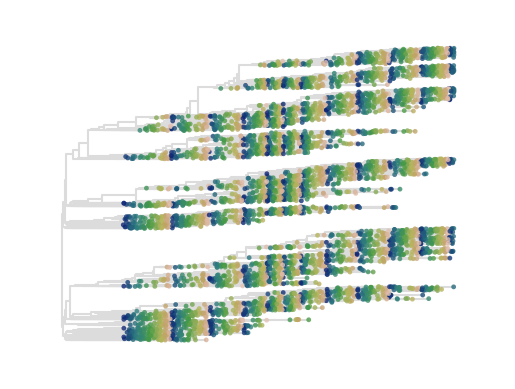

/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1124) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=radial+regime=pure+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=radial+regime=pure+viz=draw-scatter-tree+ext=.png


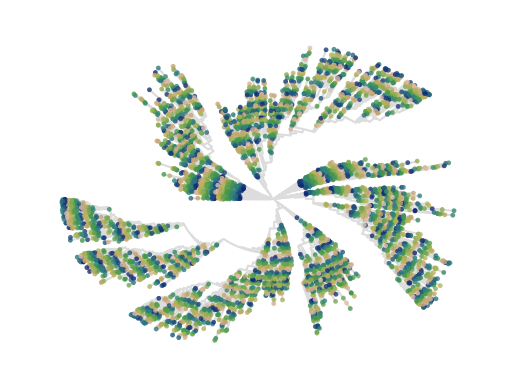

/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1122) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=vertical+regime=sweep+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=vertical+regime=sweep+viz=draw-scatter-tree+ext=.png


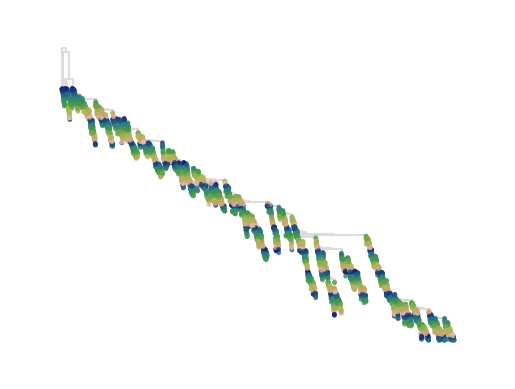

/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1118) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=horizontal+regime=sweep+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=horizontal+regime=sweep+viz=draw-scatter-tree+ext=.png


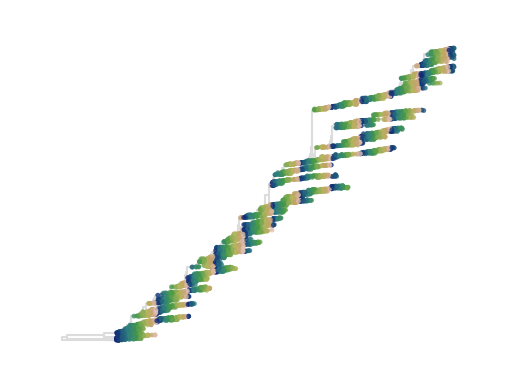

/home/runner/work/hstrat-synthesis/hstrat-synthesis/binder/pylib/tree/_draw_scatter_tree.py:104: UserWarning: 
The palette list has fewer values (100) than needed (1112) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


teeplots/2026-03-04-fossil-layers/hue=layer+layout=radial+regime=sweep+viz=draw-scatter-tree+ext=.pdf
teeplots/2026-03-04-fossil-layers/hue=layer+layout=radial+regime=sweep+viz=draw-scatter-tree+ext=.png


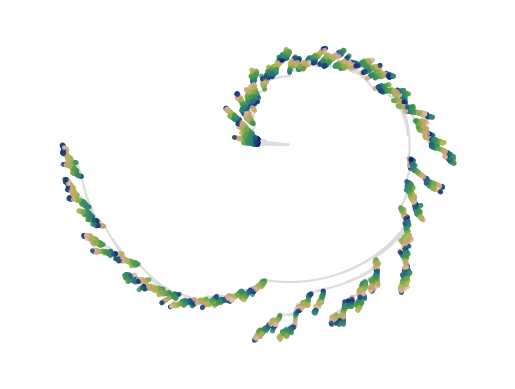

In [10]:
for regime, layout in it.product(
    ("pure", "sweep"),
    ("vertical", "horizontal", "radial"),
):
    df = df_pure if regime == "pure" else df_sweep
    with tp.teed(
        pylib.tree.draw_scatter_tree,
        pfl.alifestd_downsample_tips_asexual(df, n_downsample=5_000),
        hue="layer",
        layout=layout,
        scatter_kws=dict(
            alpha=0.8,
            edgecolor="none",
            palette=sns.color_palette("gist_earth", 120)[10:-10],
            s=12,
        ),
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="gainsboro",
                linewidth=0.5,
            ),
        ),
        teeplot_outattrs={"regime": regime},
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        pass


## Fill Template with Scatter Tree Plot


In [11]:
import pymupdf

positions_path = "assets/wse-layer-phylo-positions.pdf"
template_path = "assets/wse-layer-phylo-template.pdf"

positions_doc = pymupdf.open(positions_path)
print(f"Positions: {len(positions_doc)} page(s), size {positions_doc[0].rect}")

template_doc = pymupdf.open(template_path)
print(f"Template:  {len(template_doc)} page(s), size {template_doc[0].rect}")


Positions: 1 page(s), size Rect(0.0, 0.0, 631.1491088867188, 292.96844482421875)
Template:  1 page(s), size Rect(0.0, 0.0, 631.1491088867188, 292.96844482421875)


In [12]:
target_color = "#DEADBE"


def hex_to_rgb_float(hex_color):
    h = hex_color.lstrip("#")
    return tuple(int(h[i : i + 2], 16) / 255.0 for i in (0, 2, 4))


def find_rects_by_color(page, hex_color, tol=2 / 255):
    target = hex_to_rgb_float(hex_color)
    rects = []
    for path in page.get_drawings():
        fill = path.get("fill")
        if fill is None or len(fill) != 3:
            continue
        if all(abs(fill[i] - target[i]) < tol for i in range(3)):
            rects.append(path["rect"])
    return rects


positions_page = positions_doc[0]
deadbe_rects = find_rects_by_color(positions_page, target_color)
for r in deadbe_rects:
    print(f"  deadbe ({target_color}): {r}")

positions_doc.close()


  deadbe (#DEADBE): Rect(248.72999572753906, 0.0, 631.1480102539062, 288.8479919433594)


In [13]:
scatter_tree_path = os.path.join(
    "teeplots",
    teeplot_subdir,
    "hue=layer+layout=vertical+regime=pure+viz=draw-scatter-tree+ext=.pdf",
)
print(f"Loading scatter tree from: {scatter_tree_path}")
scatter_doc = pymupdf.open(scatter_tree_path)

# Rotate 180 degrees by creating a new document with rotated page
rotated_doc = pymupdf.open()
rotated_doc.insert_pdf(scatter_doc)
rotated_doc[0].set_rotation(180)

page = template_doc[0]
for rect in deadbe_rects:
    page.show_pdf_page(rect, rotated_doc, 0)
    print(f"  Inserted rotated scatter tree at {rect}")

output_destination = f"teeplots/{teeplot_subdir}/"
os.makedirs(output_destination, exist_ok=True)
output_path = os.path.join(output_destination, "wse-layer-phylo-filled.pdf")
template_doc.save(output_path, garbage=4, deflate=True)
template_doc.close()
scatter_doc.close()
rotated_doc.close()
print(f"\nSaved to {output_path}")


Loading scatter tree from: teeplots/2026-03-04-fossil-layers/hue=layer+layout=vertical+regime=pure+viz=draw-scatter-tree+ext=.pdf
  Inserted rotated scatter tree at Rect(248.72999572753906, 0.0, 631.1480102539062, 288.8479919433594)

Saved to teeplots/2026-03-04-fossil-layers/wse-layer-phylo-filled.pdf


In [14]:
filled_doc = pymupdf.open(output_path)
dpi = 600
mat = pymupdf.Matrix(dpi / 72, dpi / 72)
pix = filled_doc[0].get_pixmap(matrix=mat, alpha=False)
png_path = output_path.replace(".pdf", ".png")
pix.save(png_path)
filled_doc.close()
print(f"Saved {pix.width}x{pix.height} @ {dpi} DPI to {png_path}")


Saved 5260x2442 @ 600 DPI to teeplots/2026-03-04-fossil-layers/wse-layer-phylo-filled.png
